In [1]:
import pandas as pd
from pathlib import Path
from sklearn import metrics
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

In [2]:
data_dir = Path("data")
INDIR = Path("data/data_processed")
OUTDIR = Path("data/data_model")

OUTDIR.mkdir(parents=True, exist_ok=True)

In [3]:
arquivo = INDIR / "ANALISE_NOTAS_ENEM_MUNICIPIOS_BRASIL_MODELO.csv"
X_scaled = pd.read_csv(arquivo, encoding='utf-8')

In [4]:
X_scaled.head()

,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA
0,-0.767010,-1.047345,-1.199740,-1.036194,-0.259157
1,0.446097,0.790820,0.941715,1.062726,0.887811
2,-0.274033,-0.079904,-0.030879,-0.419715,-0.523999
3,-0.642115,-0.542588,-0.502852,-0.144604,0.645504
4,-0.156712,-0.447274,-0.367193,0.579409,2.836157


In [5]:
k_range = range(2, 11)
inertia_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

df_inertia = pd.DataFrame({
    'k': k_range,
    'inertia': inertia_values
}).set_index('k')

knee = KneeLocator(
    x=df_inertia.index,
    y=df_inertia['inertia'],
    curve='convex',
    direction='decreasing'
)

k_elbow = knee.knee

if k_elbow is None:
    print('Elbow não encontrado')
else:
    print(f'Elbow encontrado em k={k_elbow}')

Elbow encontrado em k=4


In [6]:
df_inertia.round(2)

,inertia
k,
2,3344.67
3,2069.35
4,1562.81
5,1317.53
6,1117.56
7,976.13
8,882.35
9,811.48
10,748.35


In [7]:
k_range = range(2, 11)

ch_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_scaled)
    score = metrics.calinski_harabasz_score(X_scaled, labels)
    ch_values.append(score)

df_ch = pd.DataFrame({
    'k': k_range,
    'calinski_harabasz': ch_values
}).set_index('k')

k_ch = df_ch['calinski_harabasz'].idxmax()
print(f"Melhor valor de k (Calinski-Harabasz): {k_ch}")

Melhor valor de k (Calinski-Harabasz): 3


In [8]:
df_ch.round(2)

,calinski_harabasz
k,
2,2687.01
3,2698.39
4,2565.75
5,2360.86
6,2286.54
7,2221.57
8,2131.31
9,2045.22
10,1986.22


In [9]:
k_range = range(2, 11)
db_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_scaled)
    score = metrics.davies_bouldin_score(X_scaled, labels)
    db_values.append(score)

df_db = pd.DataFrame({
    'k': k_range,
    'davies_bouldin': db_values
}).set_index('k')

k_db = df_db['davies_bouldin'].idxmin()
print(f"Melhor valor de k (Davies-Bouldin): {k_db}")

Melhor valor de k (Davies-Bouldin): 2


In [10]:
df_db.round(2)

,davies_bouldin
k,
2,0.71
3,0.78
4,0.86
5,0.94
6,0.93
7,0.92
8,0.97
9,0.99
10,1.02


In [11]:
k_range = range(2, 11)
silhouette_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_scaled)

    score = metrics.silhouette_score(
        X_scaled,
        labels,
        sample_size=5000,
        random_state=0
    )
    
    silhouette_values.append(score)

df_silhouette = pd.DataFrame({
    'k': k_range,
    'silhouette': silhouette_values
}).set_index('k')

k_sil = df_silhouette['silhouette'].idxmax()
k_sil

2

In [12]:
df_silhouette

,silhouette
k,
2,0.492667
3,0.421916
4,0.373553
5,0.329791
6,0.336865
7,0.322493
8,0.310934
9,0.306222
10,0.295110


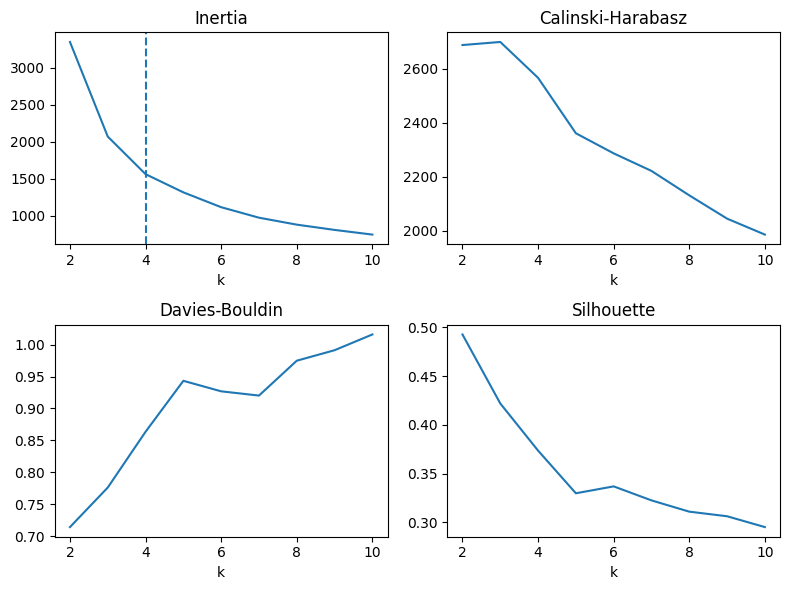

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))


df_inertia['inertia'].plot(ax=axes[0, 0], title='Inertia')

if k_elbow is not None:
    axes[0, 0].axvline(k_elbow, linestyle='--')


df_ch['calinski_harabasz'].plot(ax=axes[0, 1], title='Calinski-Harabasz')

df_db['davies_bouldin'].plot(ax=axes[1, 0], title='Davies-Bouldin')

df_silhouette['silhouette'].plot(ax=axes[1, 1], title='Silhouette')

plt.tight_layout()